In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:\\Darshan\\Da-Internship-Feb2026\\global_cancer_patients.csv')
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   Country_Region         50000 non-null  str    
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  str    
 11  Cancer_Stage           50000 non-null  str    
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8)

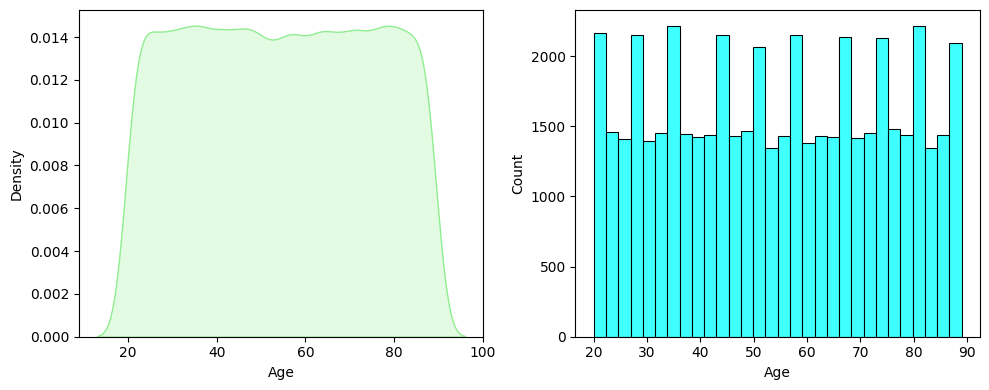

In [5]:
# plotting for age column
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(df["Age"], fill=True, color="lightgreen")

plt.subplot(1,2,2)
sns.histplot(df["Age"], bins=30,  kde=False, color="cyan")

plt.tight_layout()

In [33]:
df['Age'].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_16796\1211828385.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= df["Gender"].value_counts().index,


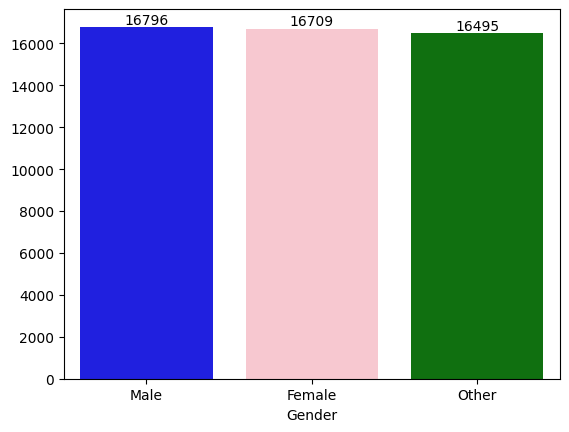

In [8]:
# Gender column
df["Gender"].value_counts()

sns.barplot(x= df["Gender"].value_counts().index,
            y= df["Gender"].value_counts().values,
            palette=["blue", "pink", "green"]
           )
for i , v in enumerate(df["Gender"].value_counts()):
    plt.text(i,v, str(v), ha="center", va="bottom")

plt.show()

In [7]:
df["Gender"].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

In [42]:
for x,y in enumerate(df['Gender'].value_counts()):
    print()

16796
16709
16495


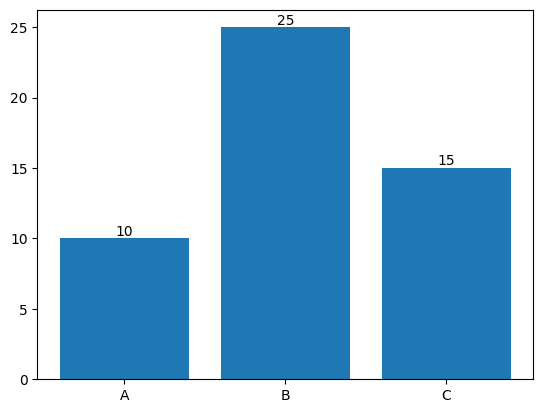

In [46]:
import matplotlib.pyplot as plt

# Sample df
categories = ['A', 'B', 'C']
values = [10, 25, 15]

# Create the bar chart and store the container object
bars = plt.bar(categories, values)

# Add labels to the bars
plt.bar_label(bars)

# Display the plot
plt.show()


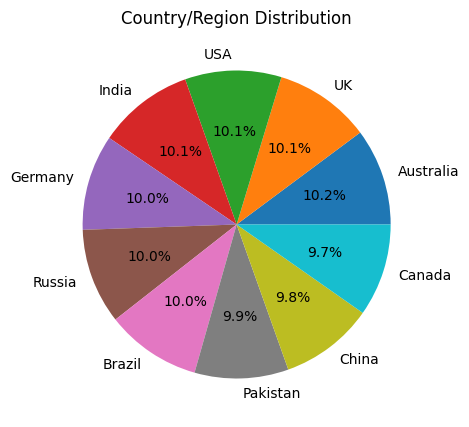

In [9]:
# countries column

country_counts= df["Country_Region"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(x=country_counts.values, 
        labels=country_counts.index,
        autopct= '%1.1f%%'
       )

plt.title("Country/Region Distribution")
plt.show()

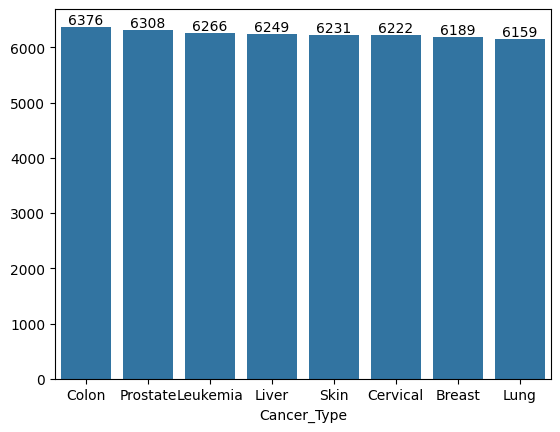

In [20]:
# cancer type 
df["Cancer_Type"].value_counts()

sns.barplot(x=df["Cancer_Type"].value_counts().index,
            y=df["Cancer_Type"].value_counts().values)

for i , v  in enumerate(df["Cancer_Type"].value_counts()):
    plt.text(i,v, str(v), ha="center", va="bottom")
plt.show()

# Task

In [13]:
# Cancer Stage

In [14]:
# plotting for treatment cost

In [16]:
# ANALYLIZING THE RISK FACTORS
column_of_interest= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
df[column_of_interest].agg(['mean','std','var','min','max'])

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
var,8.327683,8.342851,8.344985,8.303496,8.378154
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


# Determine the relationship between risk factors and cancer severity

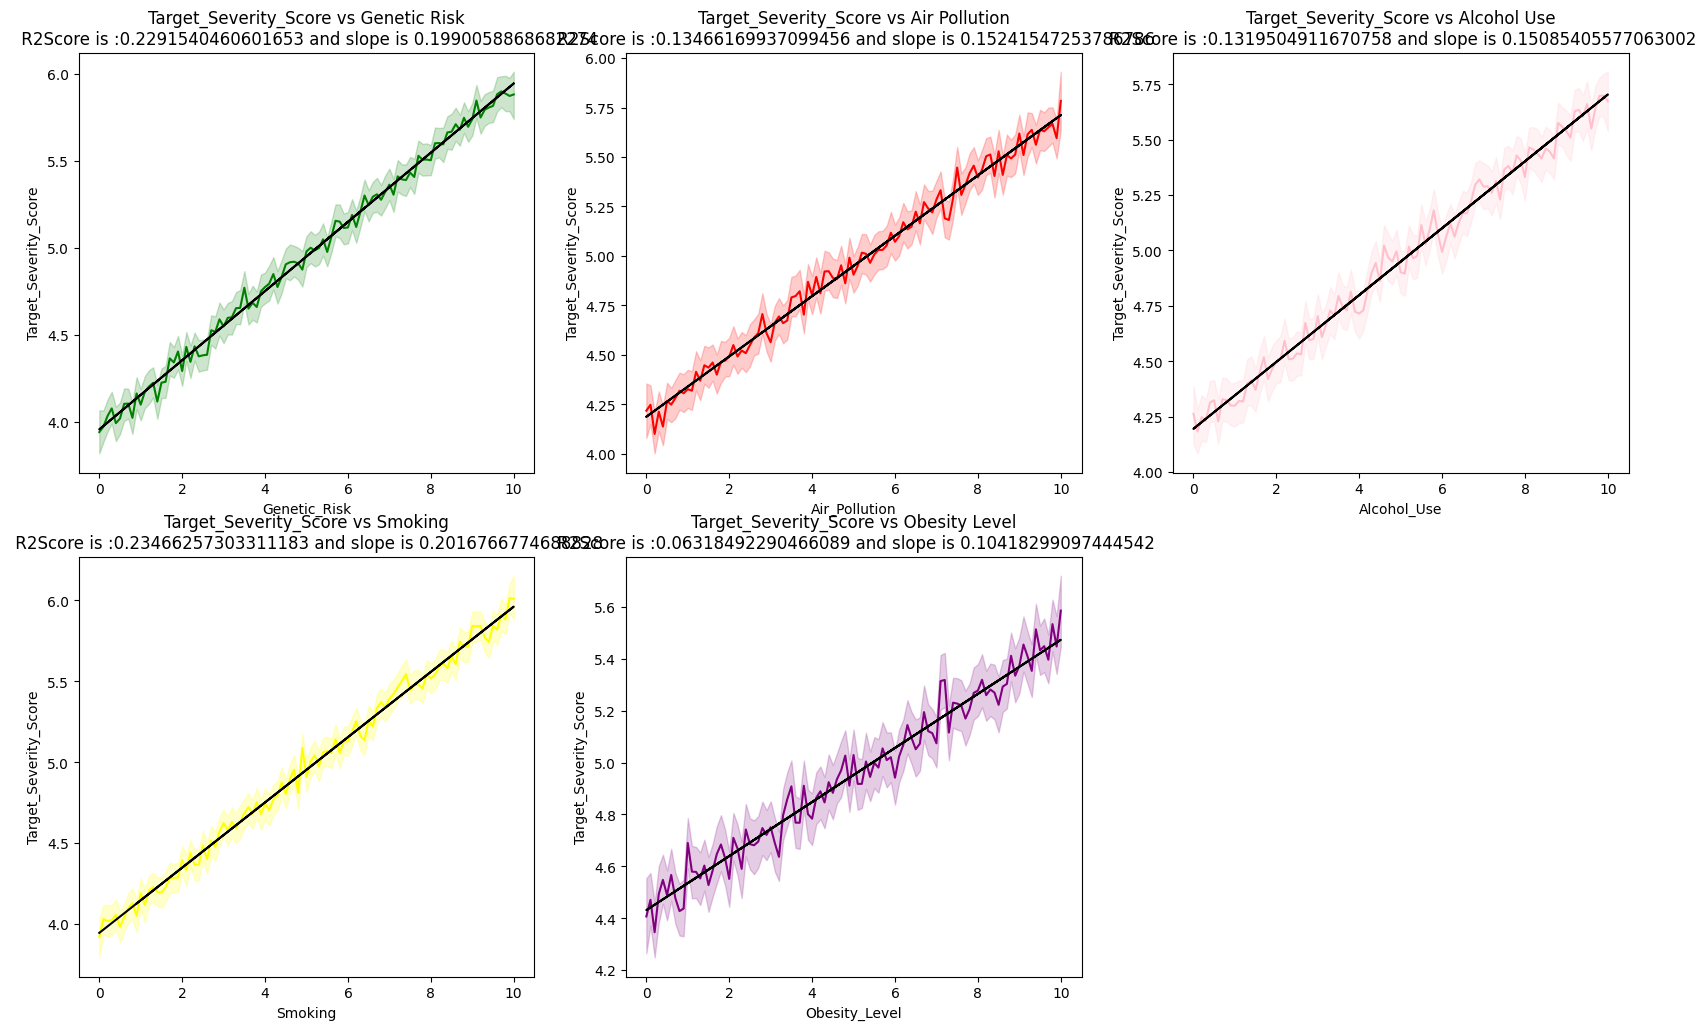

In [12]:
from scipy.stats import linregress
risk_factors= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles = ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors = ['green','red','pink','yellow','purple']

plt.figure(figsize=(20,12))
for i,(factor,title,color) in enumerate(zip(risk_factors,titles,colors),1):
    plt.subplot(2,3,i)
    x = df[factor]
    y = df['Target_Severity_Score']

    slope, intrcpt , r_value, p_value, stderr = linregress(x,y)
    r2_score = r_value**2
    sns.lineplot(x = x,y= y,data= df,color = color)
    plt.plot(x,slope*x +intrcpt,color = 'black' , label = 'Regression Line')
    plt.title(f'Target_Severity_Score vs {title}\n R2Score is :{r2_score} and slope is {slope}')
    

# y= mx+b

# Analyze the proportion of early-stage diagnoses by cancer type

In [13]:
df['Cancer_Type'].unique()

<StringArray>
['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical', 'Prostate',
 'Liver']
Length: 8, dtype: str

In [25]:
stage_count = df[df['Cancer_Type'] == 'Lung']['Cancer_Stage'].value_counts()
early_stage_count = stage_count.get('Stage 0',0) + stage_count.get('Stage I',0)
total_sum = stage_count.sum()
(early_stage_count / total_sum)*100

np.float64(38.43156356551388)

In [26]:
stage_count = df[df['Cancer_Type'] == 'Liver']['Cancer_Stage'].value_counts()
early_stage_count = stage_count.get('Stage 0',0) + stage_count.get('Stage I',0)
total_sum = stage_count.sum()
(early_stage_count / total_sum)*100

np.float64(40.614498319731155)

In [23]:
early_stage_count

np.int64(2367)

In [24]:
stage_count.sum()

np.int64(6159)

# Identify key predictors of cancer severity and survival years.

In [42]:
factor = ['Age','Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
Target = ['Target_Severity_Score','Survival_Years']

pear_corr = df[factor+Target].corr(method= 'pearson')
spearman_corr = df[factor+Target].corr(method='spearman')
pear_res = pear_cor[Target]
spear_res = spearman_corr[Target]
pd.concat([pear_res,spear_res],axis = 1,keys = ['Pearson','Spearman'])

Pearson                 \
                      Target_Severity_Score Survival_Years   
Age                               -0.001481      -0.000147   
Genetic_Risk                       0.478700       0.001708   
Air_Pollution                      0.366963       0.000893   
Alcohol_Use                        0.363250      -0.000527   
Smoking                            0.484420       0.001371   
Obesity_Level                      0.251366       0.009771   
Target_Severity_Score              1.000000       0.004161   
Survival_Years                     0.004161       1.000000   

                                   Spearman                 
                      Target_Severity_Score Survival_Years  
Age                               -0.002076      -0.000149  
Genetic_Risk                       0.472193       0.001684  
Air_Pollution                      0.357528       0.000841  
Alcohol_Use                        0.354694      -0.000543  
Smoking                            0.477881       0.001372  
Obesity_Level                      0.243152       0.009780  
Target_Severity_Score              1.000000       0.003431  
Survival_Years                     0.003431       1.000000

| Feature            | Pearson | Spearman | Interpretation                                                                                                                                               |
| ------------------ | ------- | -------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Smoking**        | 0.484   | 0.478    | Strong positive correlation. Higher smoking levels are associated with higher severity scores.                                                               |
| **Genetic_Risk**   | 0.479   | 0.472    | Strong positive correlation. Genetic predisposition is a significant factor in severity.                                                                     |
| **Air_Pollution**  | 0.367   | 0.358    | Moderate positive correlation. Suggests environmental exposure contributes to severity.                                                                      |
| **Alcohol_Use**    | 0.363   | 0.355    | Moderate positive correlation. Alcohol consumption may play a role in worsening severity.                                                                    |
| **Obesity_Level**  | 0.251   | 0.243    | Weak to moderate positive correlation. Indicates some association between obesity and severity.                                                              |
| **Treatment_Cost** | -0.466  | -0.459   | Strong negative correlation. Higher severity cases tend to have lower treatment costs, possibly reflecting late-stage diagnosis or limited treatment access. |
